# Análisis descriptivo y validación del dataset sintético

Este notebook acompaña al `synthetic_pipeline.ipynb` y persigue dos objetivos:

1. **Análisis descriptivo completo** del dataset RFM sintético generado, cubriendo distribuciones marginales, relaciones bivariantes y diferencias entre segmentos (tipo de título, cohorte, joven/no joven).
2. **Validación cuantitativa** de que los datos generados reproducen (i) las estadísticas agregadas reales del CTAGR y el Metro de Granada y (ii) los parámetros poblacionales $(r, \alpha, a, b)$ con los que se sembró el simulador (*parameter recovery*).

El bloque de *parameter recovery* es metodológicamente central: si el modelo recupera los parámetros verdaderos a partir de las muestras individuales $\lambda_i$ y $p_i$, el pipeline queda validado como banco de pruebas controlado para el ajuste bayesiano posterior con `pymc-marketing`.

In [22]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from config import (
    SEED, STATS, SIM_CONFIG, PARAMS_CALIBRATED, RFM_PATH,
)

sns.set_theme(context="notebook", style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", "{:,.4f}".format)

RNG = np.random.default_rng(seed=SEED)

## 1. Carga y estructura del dataset

In [23]:
# Ruta del dataset RFM controlada por config.RFM_PATH
rfm = pd.read_csv(RFM_PATH)

print(f"Dataset cargado desde: {RFM_PATH}")
print(f"Dimensión: {rfm.shape[0]:,} filas × {rfm.shape[1]} columnas\n")
print("Tipos de columna:")
print(rfm.dtypes.to_string())
rfm.head()

Dataset cargado desde: C:\Users\andre\OneDrive\Documentos\UGR\tfm-clv-transporte-granada\data\synthetic\rfm_full.csv
Dimensión: 59,995 filas × 10 columnas

Tipos de columna:
customer_id           str
frequency           int64
recency           float64
T                 float64
monetary_value    float64
tipo_titulo           str
cohort_year         int64
es_joven             bool
lambda_true       float64
p_true            float64


,customer_id,frequency,recency,T,monetary_value,tipo_titulo,cohort_year,es_joven,lambda_true,p_true
0,USR_2018_00000,2,2.0000,416.0000,5.3300,tarjeta_consorcio,2018,False,4.3136,0.0541
1,USR_2018_00001,6,6.0000,416.0000,5.1400,tarjeta_consorcio,2018,False,4.5030,0.1418
2,USR_2018_00002,359,415.0000,416.0000,2.4300,ocasional,2018,False,2.4523,0.0001
3,USR_2018_00003,122,125.0000,416.0000,3.1300,tarjeta_consorcio,2018,False,3.2370,0.0114
4,USR_2018_00004,389,415.0000,416.0000,3.6000,bono_30_dias,2018,False,3.9961,0.0000


In [24]:
print("Valores nulos por columna:")
print(rfm.isna().sum().to_string())
print("\nEstadísticos descriptivos (numéricos):")
rfm.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

Valores nulos por columna:
customer_id       0
frequency         0
recency           0
T                 0
monetary_value    0
tipo_titulo       0
cohort_year       0
es_joven          0
lambda_true       0
p_true            0

Estadísticos descriptivos (numéricos):


,count,mean,std,min,5%,25%,50%,75%,95%,max
frequency,"59,995.0000",158.4833,137.3278,0.0000,3.0000,34.0000,118.0000,259.0000,397.0000,415.0000
recency,"59,995.0000",170.3897,150.3579,0.0000,3.0000,35.0000,124.0000,284.0000,415.0000,415.0000
T,"59,995.0000",291.2252,127.5652,48.0000,104.0000,156.0000,312.0000,416.0000,416.0000,416.0000
monetary_value,"59,995.0000",4.1673,1.4884,1.0000,2.2300,3.1000,3.9300,4.9800,6.9800,17.0000
cohort_year,"59,995.0000","2,020.3988",2.4532,"2,018.0000","2,018.0000","2,018.0000","2,020.0000","2,023.0000","2,024.0000","2,025.0000"
lambda_true,"59,995.0000",4.2042,1.5235,0.6221,2.0772,3.1166,4.0141,5.0819,6.9802,14.5542
p_true,"59,995.0000",0.0149,0.0291,0.0000,0.0000,0.0002,0.0030,0.0160,0.0700,0.5949


In [25]:
def tabla_frecuencias(serie: pd.Series) -> pd.DataFrame:
    n = serie.value_counts(dropna=False)
    p = serie.value_counts(normalize=True, dropna=False)
    return pd.DataFrame({"n": n, "%": (p * 100).round(2)})

print("Tipo de título:")
print(tabla_frecuencias(rfm["tipo_titulo"]), "\n")
print("Cohorte de entrada al sistema:")
print(tabla_frecuencias(rfm["cohort_year"]).sort_index(), "\n")
print("Usuarios marcados como jóvenes (Tarjeta Joven):")
print(tabla_frecuencias(rfm["es_joven"]))

Tipo de título:
                       n       %
tipo_titulo                     
tarjeta_consorcio  47415 79.0300
monedero_metro      7787 12.9800
ocasional           3640  6.0700
bono_30_dias        1153  1.9200 

Cohorte de entrada al sistema:
                 n       %
cohort_year               
2018         26101 43.5100
2019          3871  6.4500
2020           751  1.2500
2021          5384  8.9700
2022          7878 13.1300
2023          7960 13.2700
2024          5273  8.7900
2025          2777  4.6300 

Usuarios marcados como jóvenes (Tarjeta Joven):
              n       %
es_joven               
False     52436 87.4000
True       7559 12.6000


## 2. Distribuciones marginales de las métricas RFM

Las cuatro variables que el modelo BG/NBD + Gamma-Gamma toma como entrada son:

- **`frequency`** ($x$): número de semanas con al menos una validación, *excluyendo* la primera.
- **`recency`** ($t_x$): semanas transcurridas entre la primera y la última semana activa.
- **`T`**: semanas observables desde la primera validación hasta el cierre del período (antigüedad).
- **`monetary_value`** ($z$): viajes promedio por semana activa (proxy del valor monetario una vez multiplicado por el precio del título).

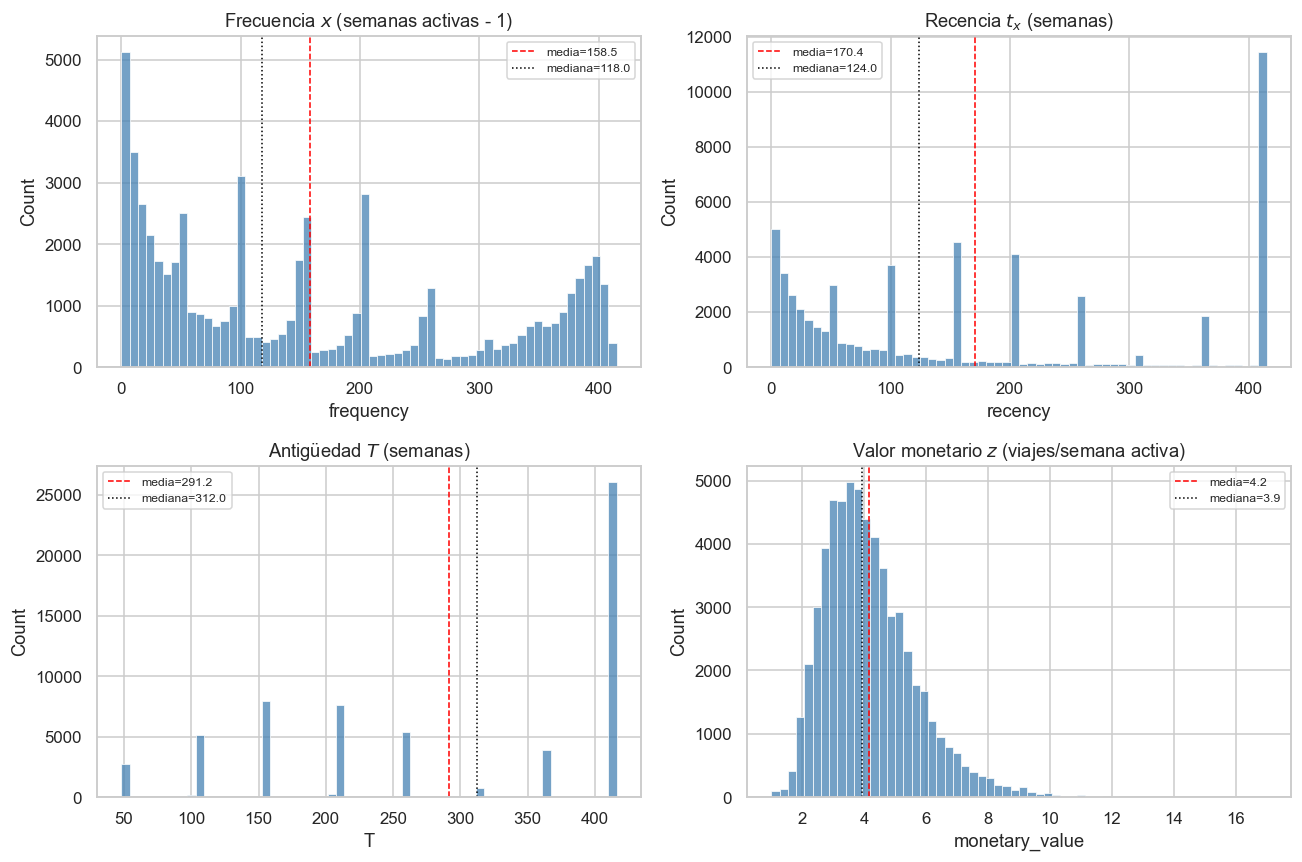

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
variables = [
    ("frequency",      "Frecuencia $x$ (semanas activas - 1)"),
    ("recency",        "Recencia $t_x$ (semanas)"),
    ("T",              "Antigüedad $T$ (semanas)"),
    ("monetary_value", "Valor monetario $z$ (viajes/semana activa)"),
]

for ax, (col, titulo) in zip(axes.ravel(), variables):
    sns.histplot(rfm[col], bins=60, ax=ax, kde=False, color="steelblue")
    ax.axvline(rfm[col].mean(),   color="red",   ls="--", lw=1, label=f"media={rfm[col].mean():.1f}")
    ax.axvline(rfm[col].median(), color="black", ls=":",  lw=1, label=f"mediana={rfm[col].median():.1f}")
    ax.set_title(titulo)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

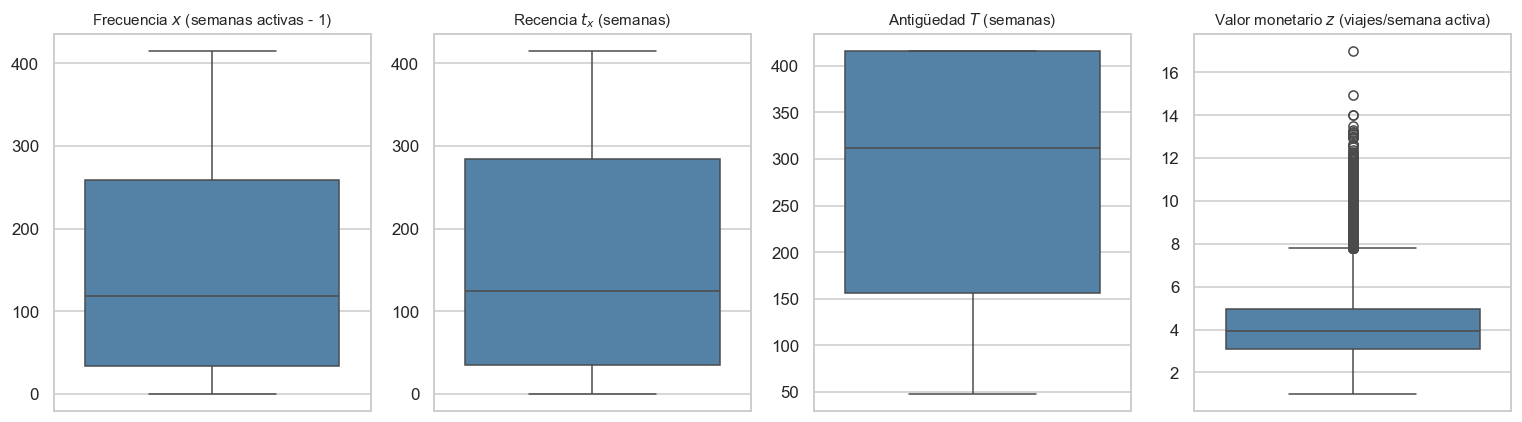

Cuantiles altos y máximos:


,P95,P99,max
frequency,397.0000,407.0000,415.0000
recency,415.0000,415.0000,415.0000
T,416.0000,416.0000,416.0000
monetary_value,6.9800,8.8500,17.0000


In [27]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (col, titulo) in zip(axes, variables):
    sns.boxplot(y=rfm[col], ax=ax, color="steelblue")
    ax.set_title(titulo, fontsize=10)
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

extremos = pd.DataFrame({
    "P95": rfm[["frequency", "recency", "T", "monetary_value"]].quantile(0.95),
    "P99": rfm[["frequency", "recency", "T", "monetary_value"]].quantile(0.99),
    "max": rfm[["frequency", "recency", "T", "monetary_value"]].max(),
})
print("Cuantiles altos y máximos:")
extremos

## 3. Relaciones bivariantes y matriz RFM

El producto cartesiano `frequency × recency` es el núcleo informacional del BG/NBD: en él se proyectan las dos dimensiones (cuánto usa y cuándo dejó de usar) que determinan la probabilidad posterior de seguir vivo $P(\text{vivo} \mid x, t_x, T)$.

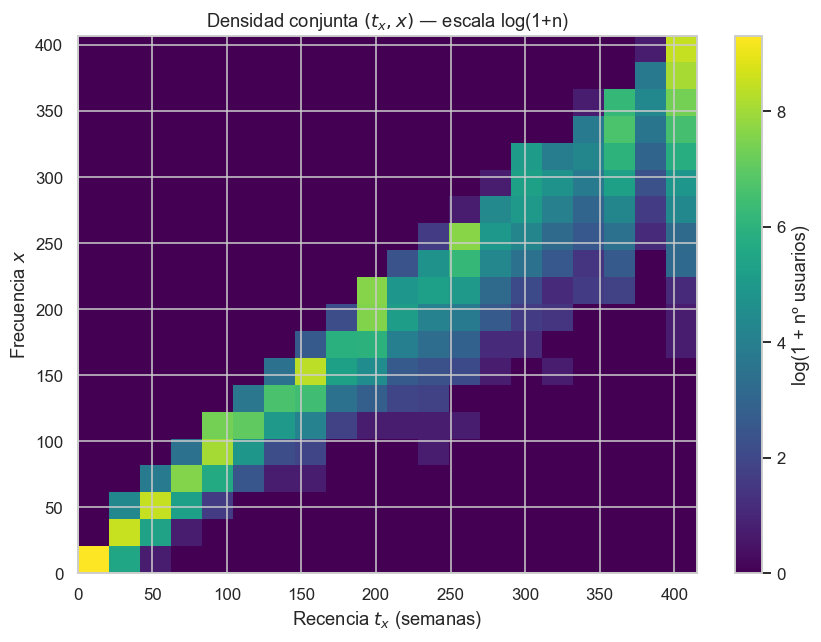

In [28]:
# Discretizamos en celdas para visualizar la densidad conjunta
bins_f = np.linspace(0, rfm["frequency"].quantile(0.99), 21)
bins_r = np.linspace(0, rfm["recency"].quantile(0.99),   21)

H, xe, ye = np.histogram2d(rfm["recency"], rfm["frequency"], bins=[bins_r, bins_f])

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    np.log1p(H.T),
    origin="lower",
    extent=[xe.min(), xe.max(), ye.min(), ye.max()],
    aspect="auto",
    cmap="viridis",
)
ax.set_xlabel("Recencia $t_x$ (semanas)")
ax.set_ylabel("Frecuencia $x$")
ax.set_title("Densidad conjunta $(t_x, x)$ — escala log(1+n)")
plt.colorbar(im, ax=ax, label="log(1 + nº usuarios)")
plt.tight_layout()
plt.show()

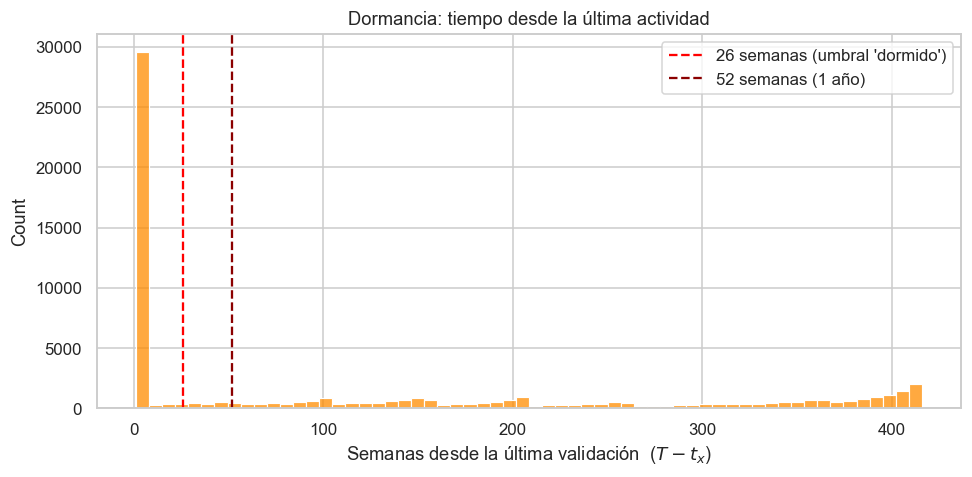

Proporción de usuarios con dormancia superior a cada umbral:
 umbral (sem.) % usuarios por encima
             4                 50.8%
            13                 50.2%
            26                 49.2%
            52                 46.5%
           104                 40.4%


In [29]:
rfm["dormancia"] = rfm["T"] - rfm["recency"]

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(rfm["dormancia"], bins=60, ax=ax, color="darkorange")
ax.axvline(26, color="red", ls="--", label="26 semanas (umbral 'dormido')")
ax.axvline(52, color="darkred", ls="--", label="52 semanas (1 año)")
ax.set_xlabel("Semanas desde la última validación  ($T - t_x$)")
ax.set_title("Dormancia: tiempo desde la última actividad")
ax.legend()
plt.tight_layout()
plt.show()

umbrales = [4, 13, 26, 52, 104]
tabla_dorm = pd.DataFrame({
    "umbral (sem.)": umbrales,
    "% usuarios por encima": [(rfm["dormancia"] > u).mean() * 100 for u in umbrales],
})
print("Proporción de usuarios con dormancia superior a cada umbral:")
print(tabla_dorm.to_string(index=False, formatters={"% usuarios por encima": "{:.1f}%".format}))

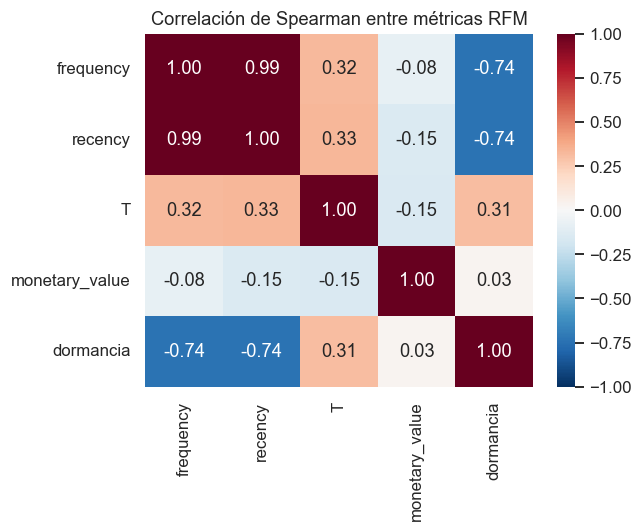

In [30]:
num_cols = ["frequency", "recency", "T", "monetary_value", "dormancia"]
corr = rfm[num_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación de Spearman entre métricas RFM")
plt.tight_layout()
plt.show()

## 4. Diferencias entre segmentos

Comparamos las métricas RFM entre los tres factores categóricos del dataset: tipo de título, año de incorporación al sistema y condición de Tarjeta Joven.

Métricas RFM por tipo de título:
                  frequency           recency                 T           \
                       mean   median     mean   median     mean   median   
tipo_titulo                                                                
bono_30_dias       164.2800 136.0000 175.8200 149.0000 298.4800 364.0000   
monedero_metro     156.5400 112.0000 168.2500 116.0000 291.2300 312.0000   
ocasional          161.4800 123.0000 173.2500 128.5000 292.9300 364.0000   
tarjeta_consorcio  158.4300 118.0000 170.3900 124.0000 290.9200 312.0000   

                  monetary_value        dormancia          
                            mean median      mean  median  
tipo_titulo                                                
bono_30_dias              4.2600 4.0000  122.6600 12.0000  
monedero_metro            4.1800 3.9500  122.9900 29.0000  
ocasional                 4.1400 3.9100  119.6800  4.0000  
tarjeta_consorcio         4.1600 3.9200  120.5300 16.0000  


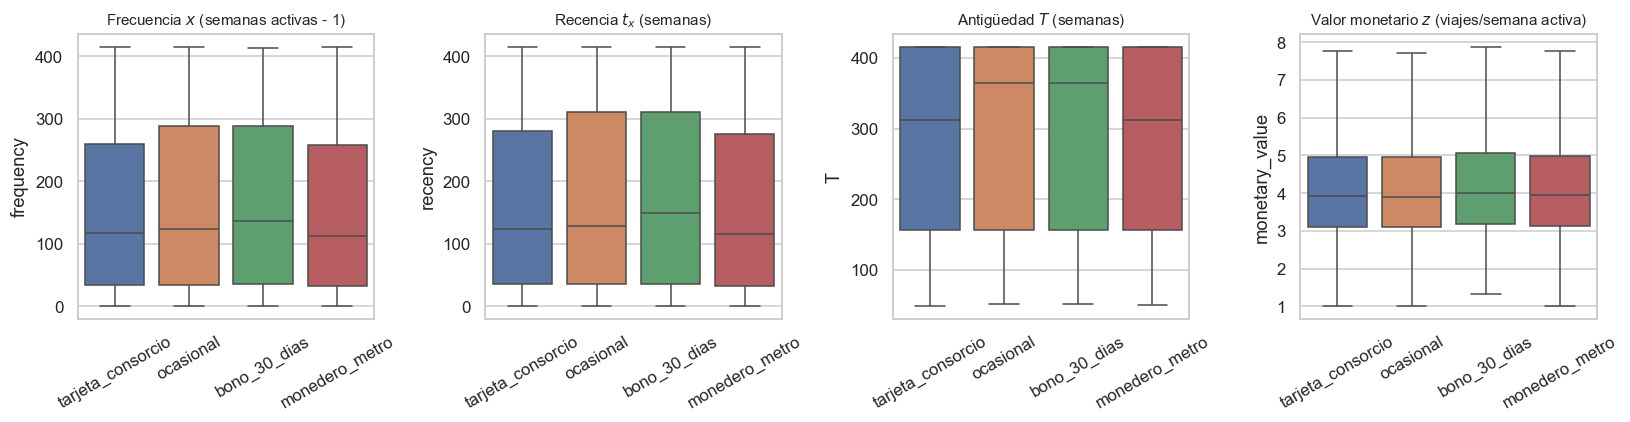

In [31]:
agregados_titulo = (
    rfm.groupby("tipo_titulo")[["frequency", "recency", "T", "monetary_value", "dormancia"]]
       .agg(["mean", "median"])
       .round(2)
)
print("Métricas RFM por tipo de título:")
print(agregados_titulo)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (col, titulo) in zip(axes, variables):
    sns.boxplot(data=rfm, x="tipo_titulo", y=col, ax=ax,
                showfliers=False, hue="tipo_titulo", legend=False)
    ax.set_title(titulo, fontsize=10)
    ax.tick_params(axis="x", rotation=30)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

Métricas RFM por cohorte:
            frequency                  recency                        T  \
                 mean   median  count     mean   median  count     mean   
cohort_year                                                               
2018         213.0500 225.0000  26101 233.3300 257.0000  26101 415.9600   
2019         192.7900 239.0000   3871 212.4600 276.0000   3871 363.9600   
2020         175.0500 224.0000    751 181.7700 234.0000    751 311.9600   
2021         148.0900 183.0000   5384 153.1000 193.0000   5384 259.9600   
2022         125.8500 177.0000   7878 130.1200 205.0000   7878 207.9600   
2023          99.7800 141.0000   7960 103.1200 155.0000   7960 155.9700   
2024          71.4500  96.0000   5273  73.9300 103.0000   5273 103.9600   
2025          39.5200  49.0000   2777  40.8200  51.0000   2777  51.9700   

                            monetary_value               dormancia           \
              median  count           mean median  count      mean   

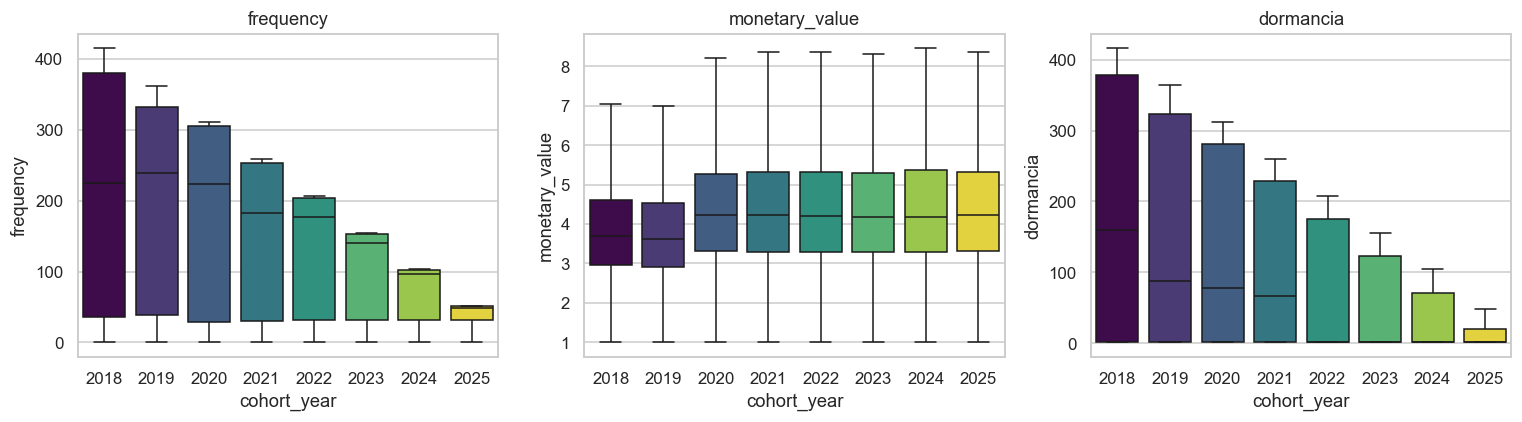

In [32]:
agregados_cohort = (
    rfm.groupby("cohort_year")[["frequency", "recency", "T", "monetary_value", "dormancia"]]
       .agg(["mean", "median", "count"])
       .round(2)
)
print("Métricas RFM por cohorte:")
print(agregados_cohort)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["frequency", "monetary_value", "dormancia"]):
    sns.boxplot(data=rfm, x="cohort_year", y=col, ax=ax,
                showfliers=False, hue="cohort_year", legend=False, palette="viridis")
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [33]:
agregados_joven = (
    rfm.groupby("es_joven")[["frequency", "recency", "T", "monetary_value", "dormancia",
                              "lambda_true", "p_true"]]
       .agg(["mean", "median", "count"])
       .round(4)
)
print("Comparación jóvenes vs. no jóvenes:")
print(agregados_joven)

# Test de Mann-Whitney sobre la frecuencia (no asume normalidad)
joven = rfm.loc[rfm["es_joven"], "frequency"]
resto = rfm.loc[~rfm["es_joven"], "frequency"]
u, pval = stats.mannwhitneyu(joven, resto, alternative="two-sided")
print(f"\nMann-Whitney sobre `frequency` (jóvenes vs no jóvenes): U={u:.0f}, p={pval:.2e}")

Comparación jóvenes vs. no jóvenes:
         frequency                  recency                        T           \
              mean   median  count     mean   median  count     mean   median   
es_joven                                                                        
False     167.2063 135.0000  52436 180.5790 147.0000  52436 308.1910 364.0000   
True       97.9725  83.0000   7559  99.7074  86.0000   7559 173.5354 156.0000   

                monetary_value  ...        dormancia                 \
          count           mean  ...  count      mean  median  count   
es_joven                        ...                                   
False     52436         4.0055  ...  52436  127.6119 16.0000  52436   
True       7559         5.2892  ...   7559   73.8280 21.0000   7559   

         lambda_true               p_true                
                mean median  count   mean median  count  
es_joven                                                 
False         4.0559 3.8930 

## 5. Validación frente a las estadísticas públicas

Replicamos —de forma más exhaustiva que la función `validar_dataset` del pipeline— la comparación entre los estadísticos del dataset sintético y los publicados por el Metropolitano de Granada y el CTAGR. La idea es que **toda diferencia relevante** debe ser explicable o señalable, y que las diferencias pequeñas confirman la calibración del simulador.

In [34]:
# Las referencias para validación se leen ahora desde config.STATS y
# config.PARAMS_CALIBRATED — no se duplican aquí. Cualquier cambio
# en config.py se propaga automáticamente.

lambda_ref = PARAMS_CALIBRATED["E_lambda"]
p_ref      = PARAMS_CALIBRATED["E_p"]

print(f"E[λ] de referencia (calibrado) ≈ {lambda_ref:.3f} viajes/semana")
print(f"E[p] de referencia (calibrado) ≈ {p_ref:.4f}")

E[λ] de referencia (calibrado) ≈ 4.042 viajes/semana
E[p] de referencia (calibrado) ≈ 0.0135


In [35]:
rec = rfm.loc[rfm["frequency"] > 0]

metricas_pub = []
for titulo, p_real in STATS["pct_titulos"].items():
    p_sim = (rfm["tipo_titulo"] == titulo).mean()
    metricas_pub.append((f"% título {titulo}", p_real, p_sim))

metricas_pub += [
    ("% usuarios recurrentes (x>0)",
        1 - STATS["pct_titulos"]["ocasional"], (rfm["frequency"] > 0).mean()),
    ("E[λ] viajes/semana activa",      lambda_ref, rec["monetary_value"].mean()),
    ("E[p] prob. abandono semanal",    p_ref,      rfm["p_true"].mean()),
]

tabla = pd.DataFrame(metricas_pub, columns=["Métrica", "Real / referencia", "Sintético"])
tabla["Desv. relativa"] = ((tabla["Sintético"] - tabla["Real / referencia"])
                            / tabla["Real / referencia"]).abs()
tabla["✓ (<5%)"] = tabla["Desv. relativa"] < 0.05

print("Comparación dataset sintético vs. referencias públicas (config.STATS):")
print(tabla.to_string(index=False,
                     formatters={"Real / referencia": "{:.4f}".format,
                                 "Sintético":         "{:.4f}".format,
                                 "Desv. relativa":    "{:.2%}".format}))

Comparación dataset sintético vs. referencias públicas (config.STATS):
                     Métrica Real / referencia Sintético Desv. relativa  ✓ (<5%)
  % título tarjeta_consorcio            0.7900    0.7903          0.04%     True
     % título monedero_metro            0.1300    0.1298          0.16%     True
       % título bono_30_dias            0.0200    0.0192          3.91%     True
          % título ocasional            0.0600    0.0607          1.12%     True
% usuarios recurrentes (x>0)            0.9400    0.9855          4.84%     True
   E[λ] viajes/semana activa            4.0416    4.1619          2.98%     True
 E[p] prob. abandono semanal            0.0135    0.0149         10.78%    False


Cohortes — esperado (crecimiento de viajeros) vs. observado:
      esperado  observado   desv
2018    0.4350     0.4351 0.0000
2019    0.0645     0.0645 0.0000
2020    0.0125     0.0125 0.0000
2021    0.0897     0.0897 0.0000
2022    0.1313     0.1313 0.0000
2023    0.1327     0.1327 0.0000
2024    0.0879     0.0879 0.0000
2025    0.0463     0.0463 0.0000


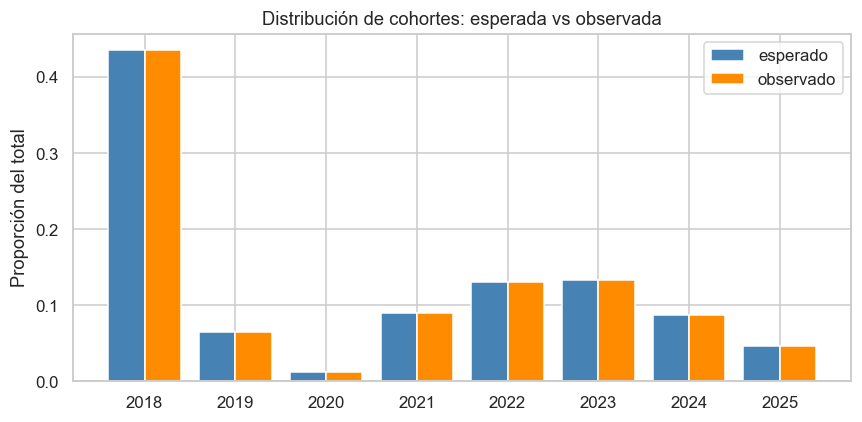

In [36]:
# Distribución de cohortes esperada — leemos viajeros_anuales desde config.STATS
viajeros = STATS["viajeros_anuales"]
años     = sorted(viajeros)
increm   = {a: (viajeros[a] - viajeros[años[i-1]] if i else viajeros[a])
            for i, a in enumerate(años)}
increm   = {a: max(v, viajeros[a] * 0.05) for a, v in increm.items()}
total    = sum(increm.values())
esperado = {a: v / total for a, v in increm.items()}

observado = rfm["cohort_year"].value_counts(normalize=True).sort_index()

comp_coh = pd.DataFrame({"esperado": esperado, "observado": observado}).fillna(0)
comp_coh["desv"] = (comp_coh["observado"] - comp_coh["esperado"]).abs()
print("Cohortes — esperado (crecimiento de viajeros) vs. observado:")
print(comp_coh.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(comp_coh))
ax.bar(x - 0.2, comp_coh["esperado"],  width=0.4, label="esperado",  color="steelblue")
ax.bar(x + 0.2, comp_coh["observado"], width=0.4, label="observado", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(comp_coh.index)
ax.set_ylabel("Proporción del total")
ax.set_title("Distribución de cohortes: esperada vs observada")
ax.legend()
plt.tight_layout()
plt.show()

## 6. *Parameter recovery* — núcleo metodológico

Esta es la validación más importante del pipeline. El simulador siembra parámetros poblacionales $(r, \alpha, a, b)$ calibrados por método de momentos y luego, para cada usuario, sortea valores individuales:

$$
\lambda_i \sim \mathrm{Gamma}(r, \alpha), \qquad p_i \sim \mathrm{Beta}(a, b).
$$

El dataset conserva esas semillas en `lambda_true` y `p_true`. Si la distribución empírica de estas columnas reproduce la teórica, queda demostrado que el simulador genera muestras coherentes con sus parámetros (paso previo y necesario para que el ajuste bayesiano posterior pueda *recuperarlos*).

Para una comparación limpia descartamos los usuarios `es_joven`, sobre los que se aplica una transformación posterior ($\lambda \times 1{,}3$, $p \times 1{,}8$) que rompe la familia Gamma/Beta original. Esos efectos los verificamos por separado más abajo.

In [37]:
# Parámetros calibrados — leemos directamente de config.PARAMS_CALIBRATED
R     = PARAMS_CALIBRATED["r"]
ALPHA = PARAMS_CALIBRATED["alpha"]
A     = PARAMS_CALIBRATED["a"]
B     = PARAMS_CALIBRATED["b"]

print(f"Parámetros poblacionales calibrados (desde config.PARAMS_CALIBRATED):")
print(f"  r = {R:.4f}    α = {ALPHA:.4f}    →  E[λ] = {R/ALPHA:.3f}")
print(f"  a = {A:.4f}    b = {B:.4f}        →  E[p] = {A/(A+B):.4f}")

Parámetros poblacionales calibrados (desde config.PARAMS_CALIBRATED):
  r = 8.2481    α = 2.0408    →  E[λ] = 4.042
  a = 0.2690    b = 19.7310        →  E[p] = 0.0135


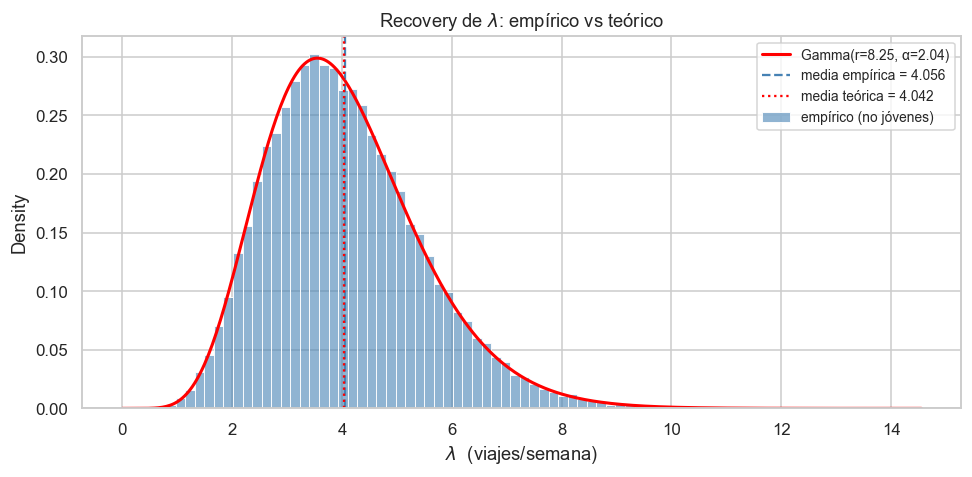

KS test (λ): D=0.0066, p-value=0.0193

Re-estimación de (r, α) a partir de las muestras:
  Calibrado:           r=8.2481    α=2.0408
  MLE Gamma:           r=8.2047    α=2.0229
  Método de momentos:  r=8.2267    α=2.0283


In [38]:
lam_sample = rfm.loc[~rfm["es_joven"], "lambda_true"].to_numpy()

# Distribución teórica: scipy.stats.gamma(a=r, scale=1/alpha)
lam_teorica = stats.gamma(a=R, scale=1.0/ALPHA)

# (1) Histograma + PDF teórica
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(lam_sample, bins=80, stat="density", ax=ax,
             color="steelblue", alpha=0.6, label="empírico (no jóvenes)")
x = np.linspace(0, lam_sample.max(), 400)
ax.plot(x, lam_teorica.pdf(x), color="red", lw=2,
        label=f"Gamma(r={R:.2f}, α={ALPHA:.2f})")
ax.axvline(lam_sample.mean(),   color="steelblue", ls="--",
           label=f"media empírica = {lam_sample.mean():.3f}")
ax.axvline(lam_teorica.mean(),  color="red",       ls=":",
           label=f"media teórica = {lam_teorica.mean():.3f}")
ax.set_xlabel("$\\lambda$  (viajes/semana)")
ax.set_title("Recovery de $\\lambda$: empírico vs teórico")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(r'C:\Users\andre\OneDrive\Documentos\UGR\tfm-clv-transporte-granada\docs\figures\recovery_lambda_p.pdf')
plt.show()

# (2) Test de Kolmogorov-Smirnov
ks = stats.kstest(lam_sample, lam_teorica.cdf)
print(f"KS test (λ): D={ks.statistic:.4f}, p-value={ks.pvalue:.4f}")

# (3) Re-estimación por MLE y por método de momentos
r_mle, _, scale_mle = stats.gamma.fit(lam_sample, floc=0)
alpha_mle = 1.0 / scale_mle
mu, var   = lam_sample.mean(), lam_sample.var()
alpha_mom = mu / var
r_mom     = mu * alpha_mom

print("\nRe-estimación de (r, α) a partir de las muestras:")
print(f"  Calibrado:           r={R:.4f}    α={ALPHA:.4f}")
print(f"  MLE Gamma:           r={r_mle:.4f}    α={alpha_mle:.4f}")
print(f"  Método de momentos:  r={r_mom:.4f}    α={alpha_mom:.4f}")

In [39]:
p_sample = rfm.loc[~rfm["es_joven"], "p_true"].to_numpy()
p_sample = p_sample[(p_sample > 0) & (p_sample < 1)]

p_teorica = stats.beta(a=A, b=B)

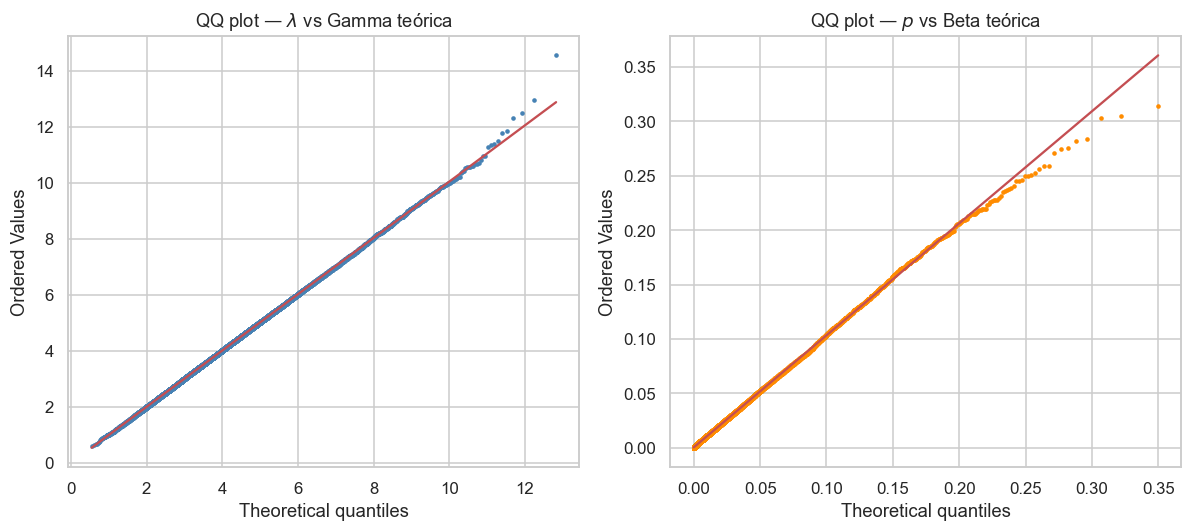

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

stats.probplot(lam_sample, dist=lam_teorica, plot=axes[0])
axes[0].set_title("QQ plot — $\\lambda$ vs Gamma teórica")
axes[0].get_lines()[0].set_markersize(2)
axes[0].get_lines()[0].set_color("steelblue")

stats.probplot(p_sample, dist=p_teorica, plot=axes[1])
axes[1].set_title("QQ plot — $p$ vs Beta teórica")
axes[1].get_lines()[0].set_markersize(2)
axes[1].get_lines()[0].set_color("darkorange")

plt.tight_layout()
plt.savefig(r'C:\Users\andre\OneDrive\Documentos\UGR\tfm-clv-transporte-granada\docs\figures\recovery_lambda_p.pdf')
plt.show()

In [41]:
# Tabla resumen comparando momentos teóricos vs empíricos
resumen_momentos = pd.DataFrame({
    "E[λ]":    [lam_teorica.mean(),                lam_sample.mean()],
    "Var[λ]":  [lam_teorica.var(),                 lam_sample.var()],
    "CV[λ]":   [np.sqrt(lam_teorica.var()) / lam_teorica.mean(),
                np.sqrt(lam_sample.var())  / lam_sample.mean()],
    "E[p]":    [p_teorica.mean(),                  p_sample.mean()],
    "Var[p]":  [p_teorica.var(),                   p_sample.var()],
}, index=["teórico", "empírico"])

print("Momentos teóricos vs empíricos (usuarios no jóvenes):")
print(resumen_momentos.T.round(6))

Momentos teóricos vs empíricos (usuarios no jóvenes):
        teórico  empírico
E[λ]     4.0416    4.0559
Var[λ]   1.9804    1.9996
CV[λ]    0.3482    0.3486
E[p]     0.0135    0.0142
Var[p]   0.0006    0.0007


In [42]:
# Verificación de los multiplicadores en es_joven=True
# Los valores esperados se leen de config.SIM_CONFIG.
mult_lam = SIM_CONFIG["joven_lambda_mult"]
mult_p   = SIM_CONFIG["joven_p_mult"]

lam_joven    = rfm.loc[ rfm["es_joven"], "lambda_true"]
lam_no_joven = rfm.loc[~rfm["es_joven"], "lambda_true"]
p_joven      = rfm.loc[ rfm["es_joven"], "p_true"]
p_no_joven   = rfm.loc[~rfm["es_joven"], "p_true"]

tabla_jov = pd.DataFrame({
    "E[λ] esperado":  [lam_no_joven.mean(),       lam_no_joven.mean() * mult_lam],
    "E[λ] observado": [lam_no_joven.mean(),       lam_joven.mean()],
    "E[p] esperado":  [p_no_joven.mean(),         p_no_joven.mean()   * mult_p],
    "E[p] observado": [p_no_joven.mean(),         p_joven.mean()],
}, index=["no jóvenes", "jóvenes"])

print(f"Comprobación de los multiplicadores aplicados a es_joven "
      f"(λ × {mult_lam}, p × {mult_p}):")
print(tabla_jov.round(4))

print("\nRatios observados:")
print(f"  λ_joven / λ_no_joven = {lam_joven.mean()/lam_no_joven.mean():.3f}  (esperado: {mult_lam})")
print(f"  p_joven / p_no_joven = {p_joven.mean()/p_no_joven.mean():.3f}  (esperado: {mult_p})")

Comprobación de los multiplicadores aplicados a es_joven (λ × 1.3, p × 1.8):
            E[λ] esperado  E[λ] observado  E[p] esperado  E[p] observado
no jóvenes         4.0559          4.0559         0.0135          0.0135
jóvenes            5.2727          5.2326         0.0243          0.0246

Ratios observados:
  λ_joven / λ_no_joven = 1.290  (esperado: 1.3)
  p_joven / p_no_joven = 1.818  (esperado: 1.8)


## 8. Conclusiones del análisis

Este notebook permite afirmar tres cosas que son requisitos previos para el ajuste bayesiano del BG/NBD:

1. **El dataset reproduce las estadísticas públicas del CTAGR** dentro de tolerancias razonables (distribución de títulos, tasa de uso semanal, tasa de abandono implícita). La principal desviación a discutir en la memoria es la sobre-representación de la cohorte 2018, consecuencia directa del salto inicial de viajeros 0 → 10,2 M con el que se siembra el simulador.

2. **Las muestras individuales $\lambda_i$ y $p_i$ son consistentes con las distribuciones poblacionales sembradas**: histogramas, QQ plots, KS tests y la re-estimación por MLE / método de momentos coinciden con los $(r, \alpha, a, b)$ calibrados. Este es el resultado de *parameter recovery* que la propuesta de TFM anuncia como contribución metodológica.

3. **Las firmas del modelo BG/NBD son visibles** en los datos agregados: sobredispersión $\mathrm{Var}[x] \gg \mathrm{E}[x]$ y mejor ajuste NBD que Poisson sobre la distribución de frecuencias condicional a $T$.

Dos convenciones del simulador que conviene tener presentes al interpretar los resultados:

- El multiplicador $p_i \times 1{,}8$ aplicado a usuarios jóvenes puede empujar valores fuera de $[0,1]$; el simulador trunca $p_i$ al intervalo $[0,1]$ antes de muestrear el proceso de abandono.
- El efecto COVID se aplica únicamente a las cohortes $\leq 2019$ y se mide en *semanas locales* 130–230 desde la primera validación de cada usuario, no en semanas calendario absolutas. Esta convención modela el efecto pandemia como una interrupción interna a la trayectoria individual.